# Data Preprocessing & Feature Engineering

**Scenario:**  
You just joined the data science team at a real estate company. Your manager hands you a raw export from the property listings database. It is a mess — missing values, inconsistent categories, extreme outliers from luxury mansions, skewed price distributions, and raw columns that no model can directly use.

**Your task:** Clean it, transform it, and engineer features that make machine learning models learn better.

| Section | Topic |
|---|---|
| 1 | Dataset with Realistic Issues |
| 2 | Handling Missing Values |
| 3 | Encoding Categorical Variables |
| 4 | Outlier Treatment |
| 5 | Feature Scaling & Normalisation |
| 6 | Feature Engineering |
| 7 | Feature Selection |
| 8 | Building an sklearn Pipeline |
| 9 | Before vs After: Does Preprocessing Help? |
| 10 | Preprocessing Checklist |

> **Why does preprocessing matter?**  
> Real-world data is never clean. Studies consistently show that data scientists spend **60–80% of their time** on preprocessing. A well-preprocessed dataset with a simple model almost always beats raw data with a complex model.

---
## 0. Setup

In [1]:
# Uncomment to install missing packages (run once)
# !pip install pandas numpy matplotlib seaborn scipy scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# sklearn — preprocessing
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, RobustScaler,
    LabelEncoder, OrdinalEncoder, OneHotEncoder
)
from sklearn.impute import SimpleImputer, KNNImputer

# sklearn — feature selection
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, f_regression
)

# sklearn — pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# sklearn — modelling
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

# Display settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (11, 5)
pd.set_option('display.max_columns', 20)
np.random.seed(42)

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 1. The Dataset — A Realistic Mess

We generate 500 property listings with **deliberate problems** baked in:

| Column | Type | Description | Problem injected |
|---|---|---|---|
| `area_sqft` | Continuous | Living area in square feet | 5% missing + 3 luxury outliers |
| `bedrooms` | Discrete | Number of bedrooms | — |
| `bathrooms` | Discrete | Number of bathrooms | 3% missing |
| `floors` | Discrete | Number of floors | — |
| `age_years` | Discrete | Age of the property | 4% missing |
| `garage_spaces` | Discrete | Garage capacity (0–3) | — |
| `has_pool` | Binary | Pool present (0/1) | — |
| `has_basement` | Binary | Basement present (0/1) | — |
| `neighborhood` | Nominal | Area category | 4% missing |
| `condition` | Ordinal | Property condition | 3% missing |
| `price` | Continuous | Sale price (USD) ← **TARGET** | Right-skewed |

**Reading the generator teaches you something important:** you can see the exact relationships we injected — this makes it easy to verify that our preprocessing later actually works.

In [2]:
N = 500

# --- Raw features ---
area_sqft     = np.random.lognormal(mean=7.3, sigma=0.4, size=N).clip(600, 5000).round()
bedrooms      = np.random.choice([1, 2, 3, 4, 5], size=N, p=[0.05, 0.20, 0.40, 0.25, 0.10])
bathrooms     = np.clip(bedrooms - np.random.randint(0, 2, N), 1, 5).astype(float)
floors        = np.random.choice([1, 2, 3], size=N, p=[0.50, 0.40, 0.10])
age_years     = np.random.exponential(scale=20, size=N).clip(0, 80).round().astype(float)
garage_spaces = np.random.choice([0, 1, 2, 3], size=N, p=[0.20, 0.45, 0.30, 0.05])
has_pool      = np.random.choice([0, 1], size=N, p=[0.75, 0.25])
has_basement  = np.random.choice([0, 1], size=N, p=[0.55, 0.45])

neighborhood = np.random.choice(
    ['Downtown', 'Suburbs', 'Uptown', 'Rural'],
    size=N, p=[0.25, 0.35, 0.25, 0.15]
)
condition_levels = ['Poor', 'Fair', 'Good', 'Excellent']
condition = np.random.choice(condition_levels, size=N, p=[0.05, 0.20, 0.50, 0.25])

# --- Price: driven by features + multipliers + noise ---
neigh_mult = {'Downtown': 1.30, 'Uptown': 1.50, 'Suburbs': 1.00, 'Rural': 0.70}
cond_mult  = {'Poor': 0.70, 'Fair': 0.85, 'Good': 1.00, 'Excellent': 1.20}

base_price = (
    50_000
    + 120   * area_sqft
    + 20_000 * bedrooms
    + 15_000 * bathrooms
    + 10_000 * floors
    - 1_200  * age_years
    + 18_000 * garage_spaces
    + 25_000 * has_pool
    + 15_000 * has_basement
)
nm    = np.array([neigh_mult[n] for n in neighborhood])
cm    = np.array([cond_mult[c]  for c in condition])
noise = np.random.normal(0, 20_000, N)
price = (base_price * nm * cm + noise).clip(50_000, 2_000_000).round(-3)

df = pd.DataFrame({
    'area_sqft':     area_sqft,
    'bedrooms':      bedrooms,
    'bathrooms':     bathrooms,
    'floors':        floors,
    'age_years':     age_years,
    'garage_spaces': garage_spaces,
    'has_pool':      has_pool,
    'has_basement':  has_basement,
    'neighborhood':  neighborhood,
    'condition':     condition,
    'price':         price
})

# --- Inject missing values ---
for col, pct in [('area_sqft', 0.05), ('bathrooms', 0.03),
                 ('age_years', 0.04), ('neighborhood', 0.04), ('condition', 0.03)]:
    idx = np.random.choice(df.index, size=int(N * pct), replace=False)
    df.loc[idx, col] = np.nan

# --- Inject 3 luxury outliers ---
lux_idx = np.random.choice(df[df['area_sqft'].notna()].index, size=3, replace=False)
df.loc[lux_idx, 'area_sqft'] = [8_500, 9_200, 11_000]
df.loc[lux_idx, 'price']     = [1_800_000, 2_100_000, 2_500_000]

print(f'Dataset shape: {df.shape[0]} properties x {df.shape[1]} columns')
print()
df.head(10)

Dataset shape: 500 properties x 11 columns



,area_sqft,bedrooms,bathrooms,floors,age_years,garage_spaces,has_pool,has_basement,neighborhood,condition,price
0,1806.0,3,2.0,2,8.0,3,0,0,Suburbs,Good,428000.0
1,1401.0,3,3.0,2,3.0,1,0,0,Suburbs,Good,391000.0
2,1918.0,3,3.0,1,NaN,2,0,0,Downtown,Fair,470000.0
3,2722.0,5,5.0,1,42.0,0,0,0,Suburbs,Poor,378000.0
4,1348.0,3,3.0,1,80.0,1,0,0,Downtown,Good,296000.0
5,1348.0,2,1.0,1,9.0,0,1,0,Rural,Good,207000.0
6,2784.0,2,1.0,2,12.0,1,0,1,Rural,Good,312000.0
7,2012.0,2,1.0,3,26.0,3,0,1,Suburbs,Good,385000.0
8,1227.0,2,2.0,1,43.0,1,0,0,Uptown,Good,351000.0
9,1839.0,2,2.0,1,18.0,0,1,1,Suburbs,Poor,282000.0


In [3]:
# Quick diagnostic — always run this on a new dataset
print('Data Types')
print(df.dtypes.to_string())
print()

print('Missing Values')
mv = df.isnull().sum()
mv_pct = (mv / len(df) * 100).round(1)
mv_df = pd.DataFrame({'count': mv, 'pct': mv_pct})
print(mv_df[mv_df['count'] > 0].to_string())
print(f'\nTotal cells: {df.size}   Missing: {mv.sum()} ({mv.sum()/df.size*100:.1f}%)')
print()

print('Numeric Summary')
df.describe().round(0)

Data Types
area_sqft        float64
bedrooms           int64
bathrooms        float64
floors             int64
age_years        float64
garage_spaces      int64
has_pool           int64
has_basement       int64
neighborhood      object
condition         object
price            float64

Missing Values
              count  pct
area_sqft        25  5.0
bathrooms        15  3.0
age_years        20  4.0
neighborhood     20  4.0
condition        15  3.0

Total cells: 5500   Missing: 95 (1.7%)

Numeric Summary


,area_sqft,bedrooms,bathrooms,floors,age_years,garage_spaces,has_pool,has_basement,price
count,475.0,500.0,485.0,500.0,480.0,500.0,500.0,500.0,500.0
mean,1654.0,3.0,3.0,2.0,19.0,1.0,0.0,0.0,442706.0
std,922.0,1.0,1.0,1.0,17.0,1.0,0.0,0.0,204152.0
min,600.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,121000.0
25%,1125.0,2.0,2.0,1.0,6.0,1.0,0.0,0.0,321000.0
50%,1483.0,3.0,3.0,2.0,14.0,1.0,0.0,0.0,411000.0
75%,1923.0,4.0,3.0,2.0,27.0,2.0,0.0,1.0,523250.0
max,11000.0,5.0,5.0,3.0,80.0,3.0,1.0,1.0,2500000.0


---
## 2. Handling Missing Values

### Why do values go missing?

This is not random. There are three types of missingness — and the type dictates your strategy:

| Type | Meaning | Example in our data | Safe to fill? |
|---|---|---|---|
| **MCAR** — Missing Completely At Random | No pattern; the missing-ness is unrelated to any feature | System glitch deleted 5 random `bathrooms` entries | Yes — any imputation works |
| **MAR** — Missing At Random | Pattern depends on *other* features (but not the missing column itself) | Luxury agents skipped `area_sqft` for high-price listings | Yes — use a model-aware imputer |
| **MNAR** — Missing Not At Random | The missing-ness depends on the missing value itself | Sellers with very old houses omitted `age_years` | Risky — the missing pattern carries information |

### Your toolkit

| Strategy | When to use |
|---|---|
| **Drop rows** | < 1% of rows affected and truly random |
| **Drop column** | > 50% missing and column is not critical |
| **Fill with mean** | Continuous feature, roughly symmetric, MCAR |
| **Fill with median** | Continuous feature with outliers, MCAR/MAR |
| **Fill with mode** | Categorical or discrete feature |
| **KNN imputation** | MAR — uses similar rows to estimate the missing value |
| **Add indicator flag** | MNAR — the fact that it's missing is itself informative |

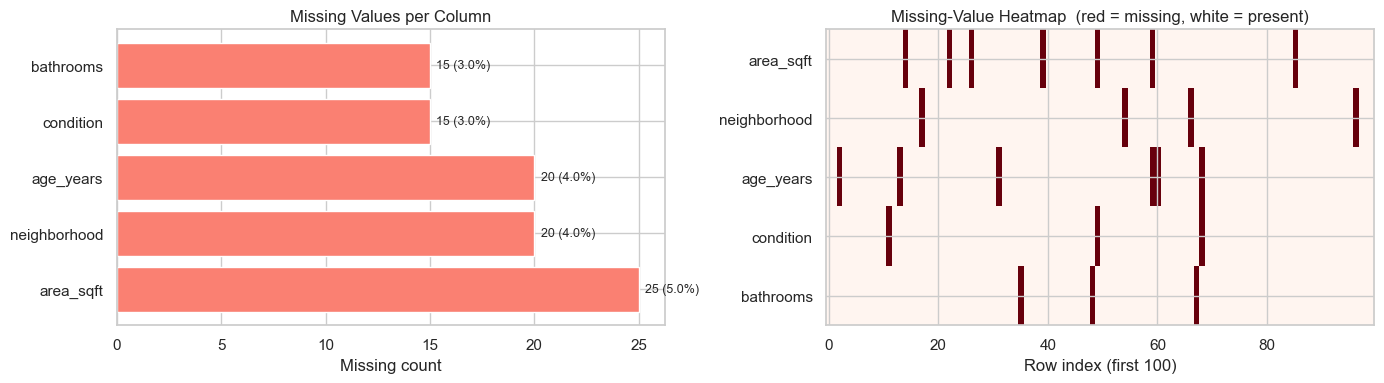

If missing values cluster in the same rows (red diagonal) → MNAR or MAR.
If they are scattered randomly → MCAR.


In [4]:
# Visualise the missing-value pattern
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart of missing counts
mv = df.isnull().sum().sort_values(ascending=False)
mv = mv[mv > 0]
axes[0].barh(mv.index, mv.values, color='salmon')
axes[0].set_xlabel('Missing count')
axes[0].set_title('Missing Values per Column')
for i, (col, val) in enumerate(mv.items()):
    axes[0].text(val + 0.3, i, f'{val} ({val/len(df)*100:.1f}%)', va='center', fontsize=9)

# Heat map of missing positions (first 100 rows)
sample_missing = df[mv.index].head(100).isnull()
axes[1].imshow(sample_missing.T, aspect='auto', cmap='Reds', interpolation='none')
axes[1].set_yticks(range(len(mv)))
axes[1].set_yticklabels(mv.index)
axes[1].set_xlabel('Row index (first 100)')
axes[1].set_title('Missing-Value Heatmap  (red = missing, white = present)')

plt.tight_layout()
plt.show()

print('If missing values cluster in the same rows (red diagonal) → MNAR or MAR.')
print('If they are scattered randomly → MCAR.')

In [5]:
# --- Strategy comparison on area_sqft ---
col = 'area_sqft'
original_values = df[col].dropna()

fill_mean   = df[col].fillna(df[col].mean())
fill_median = df[col].fillna(df[col].median())

# KNN imputation (uses all numeric columns to find similar rows)
knn_imp   = KNNImputer(n_neighbors=5)
numeric_df = df.select_dtypes(include='number')
filled_knn = knn_imp.fit_transform(numeric_df)
fill_knn   = pd.Series(filled_knn[:, numeric_df.columns.get_loc(col)], index=df.index)

# Grab only the rows that were originally missing
missing_mask = df[col].isnull()

print(f'Missing rows: {missing_mask.sum()}')
print()
print(f"  True mean (non-missing): {original_values.mean():>10.1f}")
print(f"  Fill with mean:          {fill_mean[missing_mask].mean():>10.1f}  (exactly the mean)")  
print(f"  Fill with median:        {fill_median[missing_mask].mean():>10.1f}  (exactly the median)")
print(f"  KNN fill (mean of KNN):  {fill_knn[missing_mask].mean():>10.1f}  (varies by row's neighbours)")

Missing rows: 25

  True mean (non-missing):     1654.0
  Fill with mean:              1654.0  (exactly the mean)
  Fill with median:            1483.0  (exactly the median)
  KNN fill (mean of KNN):      1615.7  (varies by row's neighbours)


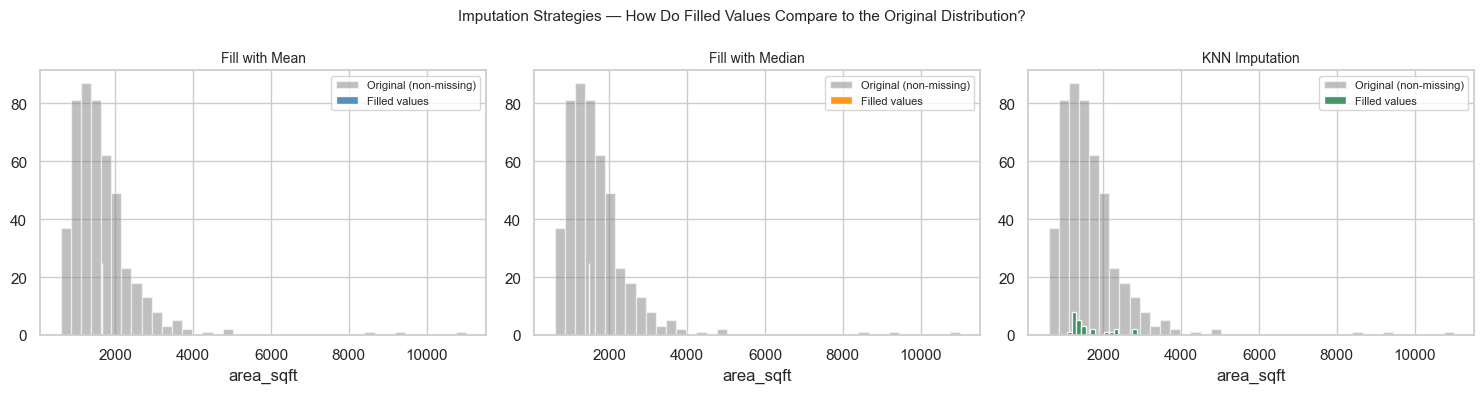

Mean/Median fill: all missing rows get the SAME value → creates an artificial spike.
KNN fill:         each missing row gets a DIFFERENT value → more realistic distribution.


In [6]:
# Visualise: how each strategy shifts the distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

strategies = [
    ('Fill with Mean',   fill_mean,   'steelblue'),
    ('Fill with Median', fill_median, 'darkorange'),
    ('KNN Imputation',   fill_knn,    'seagreen'),
]

for ax, (label, series, colour) in zip(axes, strategies):
    ax.hist(original_values, bins=40, alpha=0.5, color='gray', label='Original (non-missing)')
    ax.hist(series[missing_mask], bins=15, alpha=0.9, color=colour, label='Filled values')
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('area_sqft')
    ax.legend(fontsize=8)

plt.suptitle('Imputation Strategies — How Do Filled Values Compare to the Original Distribution?',
             fontsize=11)
plt.tight_layout()
plt.show()

print('Mean/Median fill: all missing rows get the SAME value → creates an artificial spike.')
print('KNN fill:         each missing row gets a DIFFERENT value → more realistic distribution.')

In [7]:
# --- Apply the best strategy for each column ---
df_clean = df.copy()

# Continuous with outliers → median
df_clean['area_sqft'] = df_clean['area_sqft'].fillna(df_clean['area_sqft'].median())

# Discrete, symmetric → mean (rounded to nearest integer)
df_clean['bathrooms'] = df_clean['bathrooms'].fillna(df_clean['bathrooms'].mean()).round()

# Discrete, skewed → median
df_clean['age_years'] = df_clean['age_years'].fillna(df_clean['age_years'].median())

# Categorical → mode
df_clean['neighborhood'] = df_clean['neighborhood'].fillna(df_clean['neighborhood'].mode()[0])
df_clean['condition']    = df_clean['condition'].fillna(df_clean['condition'].mode()[0])

# Verify
remaining_missing = df_clean.isnull().sum().sum()
print(f'Missing values remaining after imputation: {remaining_missing}')
print()
print('Imputation decisions:')
print('  area_sqft    → median  (has luxury outliers; mean would be pulled too high)')
print('  bathrooms    → mean    (symmetric, small range)')
print('  age_years    → median  (right-skewed exponential distribution)')
print('  neighborhood → mode    (nominal category — only option is most common)')
print('  condition    → mode    (ordinal category — most common level)')

Missing values remaining after imputation: 0

Imputation decisions:
  area_sqft    → median  (has luxury outliers; mean would be pulled too high)
  bathrooms    → mean    (symmetric, small range)
  age_years    → median  (right-skewed exponential distribution)
  neighborhood → mode    (nominal category — only option is most common)
  condition    → mode    (ordinal category — most common level)


---
## 3. Encoding Categorical Variables

Machine learning models work with **numbers**, not text. You must convert every categorical column to a numeric representation.

But **how** you encode depends on whether the categories have a natural order:

| Encoding | Used for | How it works | Risk |
|---|---|---|---|
| **Ordinal Encoding** | Ordered categories (Poor < Fair < Good < Excellent) | Map each category to an integer preserving order | Model assumes equal spacing between ranks |
| **One-Hot Encoding** | Unordered categories (Downtown, Suburbs, Rural…) | Create a binary column for each category | Adds many columns for high-cardinality features |
| **Label Encoding** | Binary or tree-based models only | Simple integer assignment | Introduces false ordering for nominal data |

> **Danger zone:** Label-encoding a nominal column (like `neighborhood`) tells the model that Rural (3) > Uptown (2) > Suburbs (1) > Downtown (0), which is meaningless and will mislead linear models.

In [8]:
# --- 3.1 Ordinal Encoding: condition (Poor < Fair < Good < Excellent) ---
condition_order = ['Poor', 'Fair', 'Good', 'Excellent']

oe = OrdinalEncoder(categories=[condition_order])
df_clean['condition_encoded'] = oe.fit_transform(df_clean[['condition']]).astype(int)

# Show the mapping
mapping = {cat: int(code) for cat, code in
           zip(oe.categories_[0], range(len(oe.categories_[0])))}
print('Ordinal Encoding — condition:')
for cat, code in mapping.items():
    print(f'  {cat:12}  →  {code}')

print()
print('Sample rows:')
df_clean[['condition', 'condition_encoded']].value_counts().sort_index().reset_index().head(8)

Ordinal Encoding — condition:
  Poor          →  0
  Fair          →  1
  Good          →  2
  Excellent     →  3

Sample rows:


,condition,condition_encoded,count
0,Excellent,3,121
1,Fair,1,110
2,Good,2,247
3,Poor,0,22


In [9]:
# --- 3.2 One-Hot Encoding: neighborhood (no natural order) ---
ohe_df = pd.get_dummies(df_clean['neighborhood'], prefix='neigh', dtype=int)

print('One-Hot Encoding — neighborhood:')
print(f'  Original column: 1 column with 4 categories')
print(f'  After OHE:       {ohe_df.shape[1]} binary columns')
print()
print(ohe_df.head(8).to_string())

# Attach to df_clean
df_clean = pd.concat([df_clean, ohe_df], axis=1)

print()
print('The "dummy variable trap": if you include ALL k dummies, one is redundant.')
print('For linear models: drop one column (drop_first=True).')
print('For tree-based models: keep all k columns (they handle it natively).')

One-Hot Encoding — neighborhood:
  Original column: 1 column with 4 categories
  After OHE:       4 binary columns

   neigh_Downtown  neigh_Rural  neigh_Suburbs  neigh_Uptown
0               0            0              1             0
1               0            0              1             0
2               1            0              0             0
3               0            0              1             0
4               1            0              0             0
5               0            1              0             0
6               0            1              0             0
7               0            0              1             0

The "dummy variable trap": if you include ALL k dummies, one is redundant.
For linear models: drop one column (drop_first=True).
For tree-based models: keep all k columns (they handle it natively).


In [10]:
# Side-by-side: label encoding vs OHE on neighborhood
# (showing WHY label encoding is wrong for nominal data)

le = LabelEncoder()
label_encoded = le.fit_transform(df_clean['neighborhood'])

print('Label Encoding — neighborhood (WRONG for linear models):')
for cat, code in zip(le.classes_, range(len(le.classes_))):
    print(f'  {cat:12} → {code}')

print()
print('Problem: the model sees Downtown(0) and Rural(3) as 3 units apart,')
print('         but they have no real numeric relationship.')
print()
print('OHE instead says: "is it Downtown? Yes/No"  "is it Rural? Yes/No"')
print('  → No false ordering, no false distance assumption.')

Label Encoding — neighborhood (WRONG for linear models):
  Downtown     → 0
  Rural        → 1
  Suburbs      → 2
  Uptown       → 3

Problem: the model sees Downtown(0) and Rural(3) as 3 units apart,
         but they have no real numeric relationship.

OHE instead says: "is it Downtown? Yes/No"  "is it Rural? Yes/No"
  → No false ordering, no false distance assumption.


---
## 4. Outlier Treatment

We detected outliers in Section 1. Now we decide what to do with them.

| Treatment | When to use | How |
|---|---|---|
| **Remove** | Clear data errors (negative age, area = 0) | Drop the rows |
| **Cap (Winsorise)** | Genuine extremes you want to keep but limit | Replace with fence value (e.g., 99th percentile) |
| **Log transform** | Right-skewed data — compresses large values | `log(x + 1)` |
| **Keep** | Tree-based models handle outliers naturally | Do nothing |

> **Never remove outliers just because they are extreme.** A $2.5M mansion is a real sale. Removing it loses real information. Instead, cap or transform — and always document your decision.

In [11]:
# Detect outliers with the IQR method
numeric_cols = ['area_sqft', 'age_years', 'price']

print(f"{'Column':>12}   {'Q1':>8}   {'Q3':>8}   {'IQR':>8}   "
      f"{'Lower fence':>12}   {'Upper fence':>12}   {'Outliers':>8}")
print('─' * 80)

outlier_info = {}
for col in numeric_cols:
    q1  = df_clean[col].quantile(0.25)
    q3  = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lo  = q1 - 1.5 * iqr
    hi  = q3 + 1.5 * iqr
    n   = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    outlier_info[col] = (lo, hi)
    print(f"{col:>12}   {q1:>8.0f}   {q3:>8.0f}   {iqr:>8.0f}   "
          f"{lo:>12.0f}   {hi:>12.0f}   {n:>8}")

      Column         Q1         Q3        IQR    Lower fence    Upper fence   Outliers
────────────────────────────────────────────────────────────────────────────────
   area_sqft       1142       1902        759              4           3040         22
   age_years          6         26         20            -24             56         21
       price     321000     523250     202250          17625         826625         15


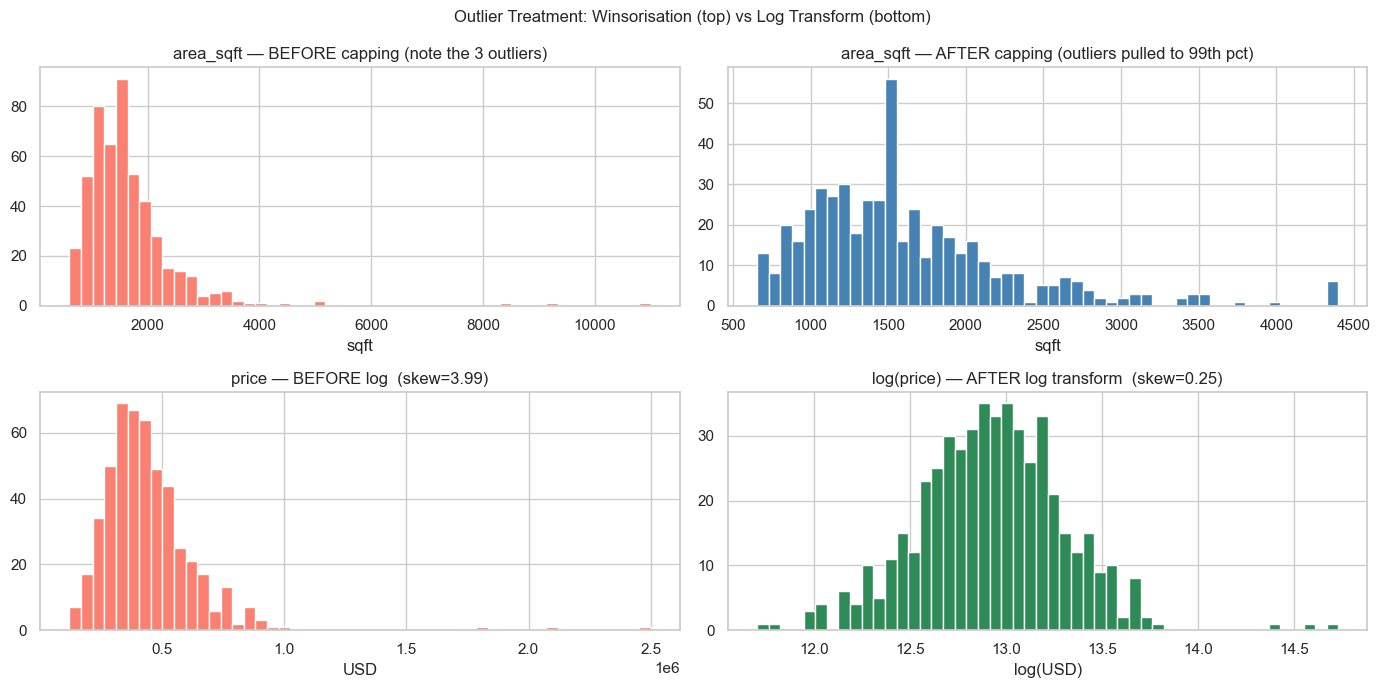

Capping:       3 outlier mansions are pulled to the 99th percentile — data kept, extremes limited.
Log transform: compressed the right tail → skewness near 0 → linear models work much better.


In [12]:
# Strategy A: Winsorisation (capping) for area_sqft
lo, hi = df_clean['area_sqft'].quantile(0.01), df_clean['area_sqft'].quantile(0.99)
df_clean['area_sqft_capped'] = df_clean['area_sqft'].clip(lower=lo, upper=hi)

# Strategy B: Log transform for price (right-skewed → more symmetric)
df_clean['log_price'] = np.log1p(df_clean['price'])   # log1p = log(x+1), safe for x=0

# Visualise the effect
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

# area_sqft before and after capping
axes[0, 0].hist(df_clean['area_sqft'], bins=50, color='salmon', edgecolor='white')
axes[0, 0].set_title('area_sqft — BEFORE capping (note the 3 outliers)')
axes[0, 0].set_xlabel('sqft')

axes[0, 1].hist(df_clean['area_sqft_capped'], bins=50, color='steelblue', edgecolor='white')
axes[0, 1].set_title('area_sqft — AFTER capping (outliers pulled to 99th pct)')
axes[0, 1].set_xlabel('sqft')

# price before and after log transform
axes[1, 0].hist(df_clean['price'], bins=50, color='salmon', edgecolor='white')
axes[1, 0].set_title(f'price — BEFORE log  (skew={df_clean["price"].skew():.2f})')
axes[1, 0].set_xlabel('USD')

axes[1, 1].hist(df_clean['log_price'], bins=50, color='seagreen', edgecolor='white')
axes[1, 1].set_title(f'log(price) — AFTER log transform  (skew={df_clean["log_price"].skew():.2f})')
axes[1, 1].set_xlabel('log(USD)')

plt.suptitle('Outlier Treatment: Winsorisation (top) vs Log Transform (bottom)', fontsize=12)
plt.tight_layout()
plt.show()

print('Capping:       3 outlier mansions are pulled to the 99th percentile — data kept, extremes limited.')
print('Log transform: compressed the right tail → skewness near 0 → linear models work much better.')

---
## 5. Feature Scaling & Normalisation

Many algorithms compute **distances** or use **gradient descent**. They are sensitive to the scale of your features.

### Without scaling:
- `price` ranges from 50,000 to 2,000,000
- `bedrooms` ranges from 1 to 5

A distance-based model will almost entirely ignore `bedrooms` — it's dwarfed by `price`. That's wrong.

| Method | Formula | Output range | Best for | Sensitive to outliers? |
|---|---|---|---|---|
| **Min-Max (Normalisation)** | $\frac{x - x_{min}}{x_{max} - x_{min}}$ | [0, 1] | Neural networks, KNN, SVM | YES |
| **Standard (Z-score)** | $\frac{x - \mu}{\sigma}$ | ~[-3, 3] | Linear/logistic regression, PCA | Somewhat |
| **Robust Scaling** | $\frac{x - Q_2}{IQR}$ | Centred on median | Data with outliers | NO |

> **Tree-based models (Random Forest, XGBoost) do NOT need scaling** — they split on thresholds, not distances.

In [13]:
# Apply all three scalers to the same column: area_sqft
col_to_scale = df_clean[['area_sqft']].copy()

minmax   = MinMaxScaler()
standard = StandardScaler()
robust   = RobustScaler()

scaled_minmax   = minmax.fit_transform(col_to_scale).flatten()
scaled_standard = standard.fit_transform(col_to_scale).flatten()
scaled_robust   = robust.fit_transform(col_to_scale).flatten()

print('Comparison — area_sqft after different scaling methods:')
print(f"{'Method':>20}   {'Min':>8}   {'Max':>8}   {'Mean':>8}   {'Std':>8}")
print('─' * 60)
for name, arr in [
    ('Original',   col_to_scale['area_sqft'].values),
    ('Min-Max',    scaled_minmax),
    ('Standard',   scaled_standard),
    ('Robust',     scaled_robust),
]:
    print(f"{name:>20}   {arr.min():>8.2f}   {arr.max():>8.2f}   {arr.mean():>8.2f}   {arr.std():>8.2f}")

Comparison — area_sqft after different scaling methods:
              Method        Min        Max       Mean        Std
────────────────────────────────────────────────────────────
            Original     600.00   11000.00    1645.47     898.23
             Min-Max       0.00       1.00       0.10       0.09
            Standard      -1.16      10.41       0.00       1.00
              Robust      -1.16      12.54       0.21       1.18


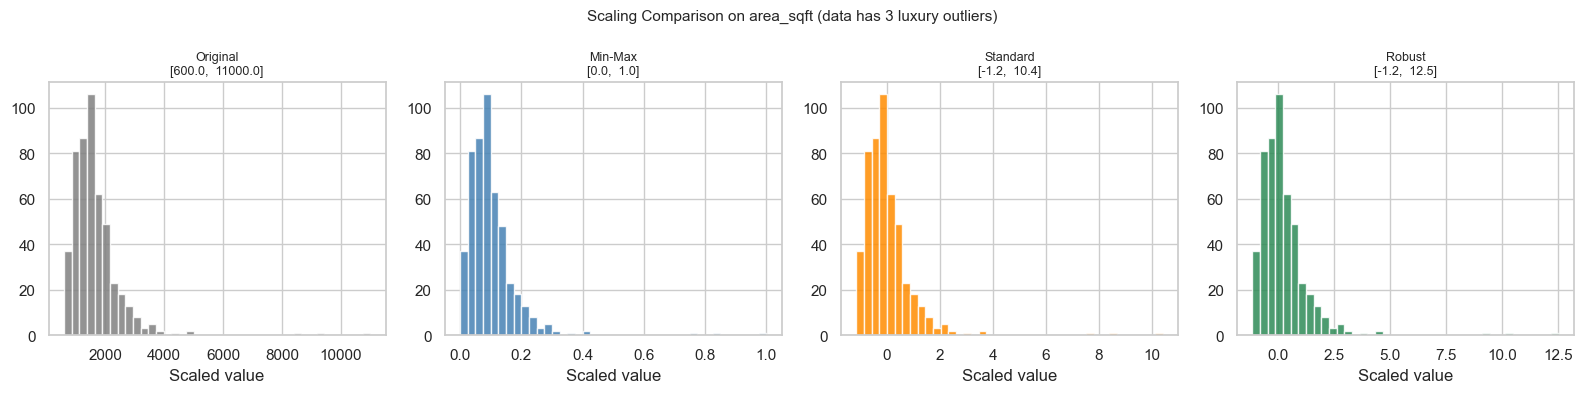

Min-Max:  outliers push everything to the far left — main cluster spans only 0–0.45
Standard: outliers pull max to +6σ — still compressed
Robust:   uses median + IQR, so outliers barely affect the bulk of the distribution


In [14]:
# Visualise how each scaler handles the 3 luxury outliers
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colours = ['gray', 'steelblue', 'darkorange', 'seagreen']
labels  = ['Original', 'Min-Max', 'Standard', 'Robust']
arrays  = [col_to_scale['area_sqft'].values, scaled_minmax, scaled_standard, scaled_robust]

for ax, arr, label, colour in zip(axes, arrays, labels, colours):
    ax.hist(arr, bins=40, color=colour, edgecolor='white', alpha=0.85)
    ax.set_title(f'{label}\n[{arr.min():.1f},  {arr.max():.1f}]', fontsize=9)
    ax.set_xlabel('Scaled value')

plt.suptitle('Scaling Comparison on area_sqft (data has 3 luxury outliers)', fontsize=11)
plt.tight_layout()
plt.show()

print('Min-Max:  outliers push everything to the far left — main cluster spans only 0–0.45')
print('Standard: outliers pull max to +6σ — still compressed')
print('Robust:   uses median + IQR, so outliers barely affect the bulk of the distribution')

In [15]:
# Show WHY scaling matters for distance-based models
# Two features: price (huge scale) vs bedrooms (tiny scale)

house_A = np.array([300_000, 3])   # $300k, 3 bedrooms
house_B = np.array([310_000, 1])   # $310k, 1 bedroom
house_C = np.array([300_000, 5])   # $300k, 5 bedrooms

def euclidean(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

print('Euclidean distances WITHOUT scaling:')
print(f'  A vs B (same price, very different bedrooms): {euclidean(house_A, house_B):>12.0f}')
print(f'  A vs C (same price, different bedrooms):      {euclidean(house_A, house_C):>12.0f}')
print()
print('bedrooms contributes essentially ZERO to the distance — overwhelmed by price scale.')
print()

# After standard scaling
sample = np.array([[300_000, 3], [310_000, 1], [300_000, 5], [280_000, 4]])
scaler = StandardScaler()
scaler.fit(sample)

sA, sB, sC = scaler.transform([house_A, house_B, house_C])

print('Euclidean distances AFTER Standard Scaling:')
print(f'  A vs B (different bedrooms):                  {euclidean(sA, sB):>12.4f}')
print(f'  A vs C (different bedrooms):                  {euclidean(sA, sC):>12.4f}')
print()
print('Now bedrooms contributes meaningfully to the distance.')

Euclidean distances WITHOUT scaling:
  A vs B (same price, very different bedrooms):        10000
  A vs C (same price, different bedrooms):                 2

bedrooms contributes essentially ZERO to the distance — overwhelmed by price scale.

Euclidean distances AFTER Standard Scaling:
  A vs B (different bedrooms):                        1.6342
  A vs C (different bedrooms):                        1.3522

Now bedrooms contributes meaningfully to the distance.


---
## 6. Feature Engineering

Feature engineering is the art of **creating new columns from existing ones** to give the model more expressive power.

> A model can only learn from what you give it. If the relationship between `area_sqft` and `price` is non-linear, a raw `area_sqft` column may not capture it — but `area_sqft²` or `log(area_sqft)` might.

### Types of feature engineering:

| Technique | What it does | Example |
|---|---|---|
| **Log/sqrt transform** | Compress right-skewed features | `log(area_sqft)` |
| **Binning** | Convert continuous → categorical buckets | age → 'New', 'Mid', 'Old' |
| **Interaction features** | Capture joint effects of two features | `bedrooms × bathrooms` |
| **Ratio features** | Normalise one feature by another | `area_sqft / bedrooms` |
| **Polynomial features** | Add higher-order terms | `area_sqft²` |
| **Domain-driven** | Use subject knowledge | `total_rooms = bedrooms + bathrooms` |

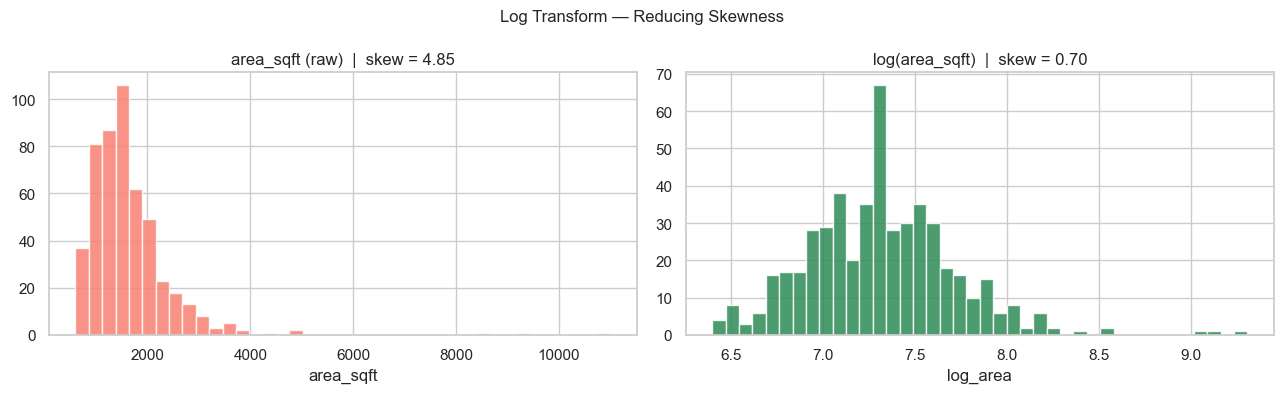

Pearson r with price:  area_sqft = 0.745   log(area_sqft) = 0.608

Log transform can IMPROVE correlation with the target by linearising the relationship.


In [16]:
# --- 6.1 Log transform: area_sqft is right-skewed ---
df_clean['log_area'] = np.log1p(df_clean['area_sqft'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, label, colour in zip(
    axes,
    ['area_sqft', 'log_area'],
    ['area_sqft (raw)', 'log(area_sqft)'],
    ['salmon', 'seagreen']
):
    ax.hist(df_clean[col], bins=40, color=colour, edgecolor='white', alpha=0.85)
    ax.set_title(f"{label}  |  skew = {df_clean[col].skew():.2f}")
    ax.set_xlabel(col)

plt.suptitle('Log Transform — Reducing Skewness', fontsize=12)
plt.tight_layout()
plt.show()

# Correlation with price before/after transform
r_raw = df_clean['area_sqft'].corr(df_clean['price'])
r_log = df_clean['log_area'].corr(df_clean['price'])
print(f'Pearson r with price:  area_sqft = {r_raw:.3f}   log(area_sqft) = {r_log:.3f}')
print()
print('Log transform can IMPROVE correlation with the target by linearising the relationship.')

Age distribution by category:
age_category
New (0-5yr)              110
Modern (5-20yr)          218
Established (20-40yr)    113
Vintage (40+yr)           59



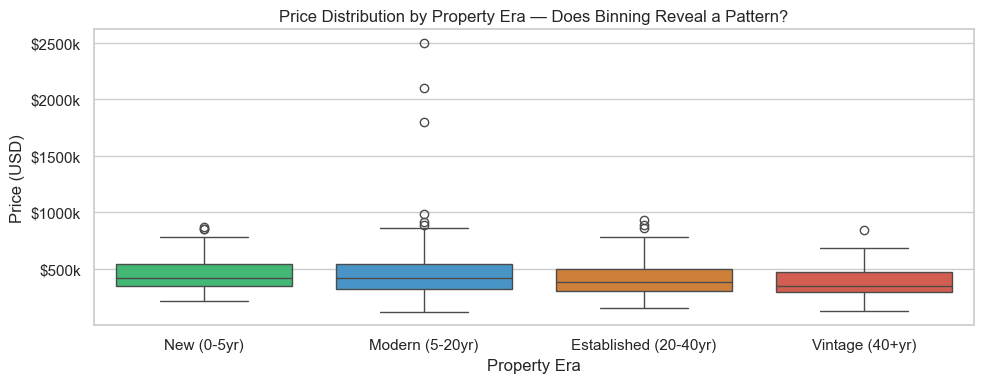

Binning converts a continuous feature into groups — useful when the relationship
with the target is step-like (e.g., new builds command a premium regardless of exact age).


In [17]:
# --- 6.2 Binning: age_years → property era ---
bins   = [-1, 5, 20, 40, 80]
labels = ['New (0-5yr)', 'Modern (5-20yr)', 'Established (20-40yr)', 'Vintage (40+yr)']

df_clean['age_category'] = pd.cut(df_clean['age_years'], bins=bins, labels=labels)

print('Age distribution by category:')
print(df_clean['age_category'].value_counts().sort_index().to_string())
print()

# Does age category separate prices well?
fig, ax = plt.subplots(figsize=(10, 4))
order = labels
palette = {'New (0-5yr)': '#2ecc71', 'Modern (5-20yr)': '#3498db',
           'Established (20-40yr)': '#e67e22', 'Vintage (40+yr)': '#e74c3c'}
sns.boxplot(data=df_clean, x='age_category', y='price', order=order,
            palette=palette, hue='age_category', legend=False, ax=ax)
ax.set_title('Price Distribution by Property Era — Does Binning Reveal a Pattern?')
ax.set_xlabel('Property Era')
ax.set_ylabel('Price (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
plt.tight_layout()
plt.show()

print('Binning converts a continuous feature into groups — useful when the relationship')
print('with the target is step-like (e.g., new builds command a premium regardless of exact age).')

In [18]:
# --- 6.3 Domain-driven features ---

# Total rooms = bedrooms + bathrooms
df_clean['total_rooms'] = df_clean['bedrooms'] + df_clean['bathrooms']

# Space per room (area_sqft / total_rooms)  → proxy for room size
df_clean['sqft_per_room'] = (df_clean['area_sqft'] / df_clean['total_rooms']).round(1)

# Amenity score (pool + basement + garage spaces)
df_clean['amenity_score'] = (
    df_clean['has_pool']
    + df_clean['has_basement']
    + (df_clean['garage_spaces'] > 0).astype(int)
)

# Value density: price per sqft (only for inspection — don't leak target into features!)
# This is just to show the concept; we won't use it as a model feature.
df_clean['price_per_sqft'] = (df_clean['price'] / df_clean['area_sqft']).round(0)

print('New engineered features added:')
engineered = ['total_rooms', 'sqft_per_room', 'amenity_score']
print(df_clean[engineered].describe().round(1).to_string())
print()

# Correlations of new features with price
all_numeric = df_clean.select_dtypes(include='number').columns
corr_with_price = df_clean[all_numeric].corr()['price'].drop('price').sort_values(key=abs, ascending=False)

print('Top 10 features correlated with price (including new engineered ones):')
for col, r in corr_with_price.head(10).items():
    bar  = '█' * int(abs(r) * 30)
    sign = '+' if r >= 0 else '-'
    tag  = '  ← NEW' if col in ['total_rooms', 'sqft_per_room', 'amenity_score', 'log_area', 'log_price'] else ''
    print(f'  {col:>22}  r={r:+.3f}  {sign}{bar}{tag}')

New engineered features added:
       total_rooms  sqft_per_room  amenity_score
count        500.0          500.0          500.0
mean           5.8          332.2            1.5
std            2.1          236.6            0.8
min            2.0           82.9            0.0
25%            4.0          185.7            1.0
50%            6.0          271.8            1.0
75%            7.0          401.3            2.0
max           10.0         2125.0            3.0

Top 10 features correlated with price (including new engineered ones):
               log_price  r=+0.911  +███████████████████████████  ← NEW
               area_sqft  r=+0.745  +██████████████████████
                log_area  r=+0.608  +██████████████████  ← NEW
        area_sqft_capped  r=+0.595  +█████████████████
           sqft_per_room  r=+0.379  +███████████  ← NEW
            neigh_Uptown  r=+0.297  +████████
             neigh_Rural  r=-0.272  -████████
       condition_encoded  r=+0.259  +███████
          pri

In [19]:
# --- 6.4 Interaction feature: does condition × neighborhood add signal? ---
df_clean['cond_x_neigh'] = df_clean['condition_encoded'] * df_clean['neigh_Uptown']

r_cond  = df_clean['condition_encoded'].corr(df_clean['price'])
r_neigh = df_clean['neigh_Uptown'].corr(df_clean['price'])
r_inter = df_clean['cond_x_neigh'].corr(df_clean['price'])

print('Interaction Feature — condition_encoded × neigh_Uptown:')
print(f'  condition_encoded alone:      r = {r_cond:+.3f}')
print(f'  neigh_Uptown alone:           r = {r_neigh:+.3f}')
print(f'  condition × Uptown combined:  r = {r_inter:+.3f}')
print()
print('Interpretation: An Excellent condition house in Uptown gets a price premium')
print('that is MORE than the sum of "Excellent" and "Uptown" separately.')
print('The interaction captures this joint effect.')

Interaction Feature — condition_encoded × neigh_Uptown:
  condition_encoded alone:      r = +0.259
  neigh_Uptown alone:           r = +0.297
  condition × Uptown combined:  r = +0.334

Interpretation: An Excellent condition house in Uptown gets a price premium
that is MORE than the sum of "Excellent" and "Uptown" separately.
The interaction captures this joint effect.


---
## 7. Feature Selection

More features ≠ better model. Too many features cause:
- **Overfitting** — the model memorises noise instead of learning patterns
- **Multicollinearity** — correlated features confuse linear models
- **Slow training** — more columns = more computation
- **The curse of dimensionality** — distance-based models degrade in high dimensions

### Three approaches:

| Method | Idea | When |
|---|---|---|
| **Correlation filter** | Drop features with near-zero correlation to target | Quick first pass |
| **Variance threshold** | Drop features that hardly change at all | Always check binary / near-constant cols |
| **SelectKBest** | Statistical test ranks features by relationship with target | Before any model |
| **Recursive Feature Elimination (RFE)** | Train model, remove weakest feature, repeat | Slower but model-aware |

In [20]:
# Build our feature matrix (numeric columns only, no leakage)
exclude = ['price', 'log_price', 'price_per_sqft', 'neighborhood', 'condition', 'age_category']
feature_cols = [c for c in df_clean.select_dtypes(include='number').columns
                if c not in exclude]

X = df_clean[feature_cols].copy()
y = df_clean['price']

print(f'Feature matrix shape: {X.shape}')
print(f'Features: {feature_cols}')

Feature matrix shape: (500, 19)
Features: ['area_sqft', 'bedrooms', 'bathrooms', 'floors', 'age_years', 'garage_spaces', 'has_pool', 'has_basement', 'condition_encoded', 'neigh_Downtown', 'neigh_Rural', 'neigh_Suburbs', 'neigh_Uptown', 'area_sqft_capped', 'log_area', 'total_rooms', 'sqft_per_room', 'amenity_score', 'cond_x_neigh']


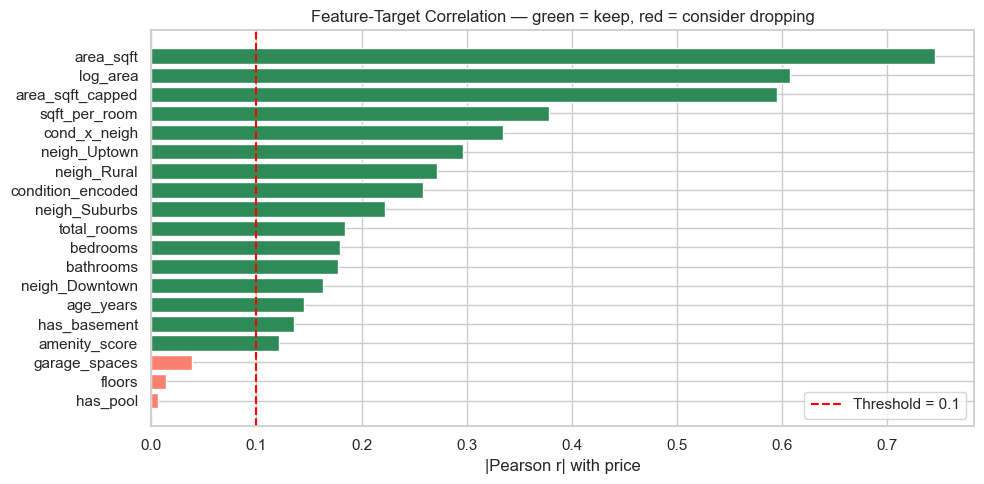

Features above threshold (16): ['area_sqft', 'log_area', 'area_sqft_capped', 'sqft_per_room', 'cond_x_neigh', 'neigh_Uptown', 'neigh_Rural', 'condition_encoded', 'neigh_Suburbs', 'total_rooms', 'bedrooms', 'bathrooms', 'neigh_Downtown', 'age_years', 'has_basement', 'amenity_score']
Features below threshold (3): ['garage_spaces', 'floors', 'has_pool']


In [21]:
# --- 7.1 Correlation filter ---
THRESHOLD = 0.1   # drop features with |r| < 0.1 with the target

corr_series = X.corrwith(y).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colours = ['seagreen' if r >= THRESHOLD else 'salmon' for r in corr_series]
ax.barh(corr_series.index[::-1], corr_series.values[::-1], color=colours[::-1])
ax.axvline(THRESHOLD, color='red', ls='--', lw=1.5, label=f'Threshold = {THRESHOLD}')
ax.set_xlabel('|Pearson r| with price')
ax.set_title('Feature-Target Correlation — green = keep, red = consider dropping')
ax.legend()
plt.tight_layout()
plt.show()

weak_features = corr_series[corr_series < THRESHOLD].index.tolist()
strong_features = corr_series[corr_series >= THRESHOLD].index.tolist()

print(f'Features above threshold ({len(strong_features)}): {strong_features}')
print(f'Features below threshold ({len(weak_features)}): {weak_features}')

In [22]:
# --- 7.2 Variance Threshold ---
# A feature with near-zero variance carries almost no information
VAR_THRESHOLD = 0.01

sel = VarianceThreshold(threshold=VAR_THRESHOLD)
sel.fit(X.fillna(0))   # fill NaN temporarily just for fitting

variances = pd.Series(sel.variances_, index=X.columns).sort_values()

print('Feature variances (sorted ascending):')
print()
for feat, var in variances.items():
    flag = '  DROPPED' if var < VAR_THRESHOLD else ''
    bar  = '█' * min(int(var / variances.max() * 30), 30)
    print(f'  {feat:>22}: {var:>10.4f}  {bar}{flag}')

dropped_var = variances[variances < VAR_THRESHOLD].index.tolist()
print(f'\nDropped by variance threshold: {dropped_var}')

Feature variances (sorted ascending):

             neigh_Rural:     0.1086  
                log_area:     0.1613  
                has_pool:     0.1771  
            neigh_Uptown:     0.1814  
          neigh_Downtown:     0.1914  
           neigh_Suburbs:     0.2356  
            has_basement:     0.2477  
                  floors:     0.4325  
           amenity_score:     0.5898  
       condition_encoded:     0.6336  
           garage_spaces:     0.7200  
            cond_x_neigh:     0.8650  
                bedrooms:     1.0350  
               bathrooms:     1.2160  
             total_rooms:     4.2320  
               age_years:   292.8079  
           sqft_per_room: 55858.3193  ██
        area_sqft_capped: 452678.5891  ████████████████
               area_sqft: 806818.0528  ██████████████████████████████

Dropped by variance threshold: []


In [23]:
# --- 7.3 SelectKBest (F-test for regression) ---
# F-test asks: is there a statistically significant linear relationship with the target?

K = 8  # select top 8 features

X_filled = X.fillna(X.median())   # impute for the selector
selector  = SelectKBest(score_func=f_regression, k=K)
selector.fit(X_filled, y)

scores_df = pd.DataFrame({
    'feature': X.columns,
    'f_score': selector.scores_,
    'p_value': selector.pvalues_,
    'selected': selector.get_support()
}).sort_values('f_score', ascending=False)

print(f'SelectKBest (k={K}) — F-test scores:')
print()
print(f"{'Feature':>22}   {'F-score':>10}   {'p-value':>12}   {'Selected':>10}")
print('─' * 65)
for _, row in scores_df.iterrows():
    flag = '  YES' if row['selected'] else ''
    p    = f"{row['p_value']:.2e}" if row['p_value'] < 0.001 else f"{row['p_value']:.4f}"
    print(f"{row['feature']:>22}   {row['f_score']:>10.1f}   {p:>12}   {flag}")

print()
print(f'Top {K} selected features:', scores_df[scores_df['selected']]['feature'].tolist())

SelectKBest (k=8) — F-test scores:

               Feature      F-score        p-value     Selected
─────────────────────────────────────────────────────────────────
             area_sqft        621.5       1.22e-89     YES
              log_area        291.6       8.29e-52     YES
      area_sqft_capped        272.3       4.08e-49     YES
         sqft_per_room         83.3       1.72e-18     YES
          cond_x_neigh         62.5       1.71e-14     YES
          neigh_Uptown         48.1       1.29e-11     YES
           neigh_Rural         39.8       6.33e-10     YES
     condition_encoded         35.7       4.29e-09     YES
         neigh_Suburbs         26.0       4.97e-07   
           total_rooms         17.4       3.50e-05   
              bedrooms         16.6       5.40e-05   
             bathrooms         16.2       6.58e-05   
        neigh_Downtown         13.6       2.52e-04   
             age_years         10.7         0.0011   
          has_basement          9.3   

---
## 8. Building an sklearn Pipeline

The **biggest mistake** beginners make with preprocessing:

> Fitting the scaler / imputer on the **entire dataset** before splitting into train/test.

This causes **data leakage** — the model "sees" information from the test set during training, leading to overoptimistic evaluation.

**The correct workflow:**

```
Raw data
   ↓
Train / Test split  ← split FIRST, preprocess SECOND
   ↓               ↓
  fit()          transform()   ← scalers/imputers learn from train ONLY
   ↓               ↓
Train (scaled)   Test (scaled with train's stats)
   ↓
  model.fit()
```

An **sklearn Pipeline** handles this automatically and safely.

In [24]:
# --- Rebuild clean input for the pipeline (raw data, no manual transforms) ---
df_raw = df.copy()   # start from the original messy data

# Define feature groups
numeric_features     = ['area_sqft', 'bedrooms', 'bathrooms', 'floors',
                        'age_years', 'garage_spaces', 'has_pool', 'has_basement']
nominal_features     = ['neighborhood']
ordinal_features     = ['condition']
condition_categories = [['Poor', 'Fair', 'Good', 'Excellent']]

X_raw = df_raw[numeric_features + nominal_features + ordinal_features]
y_raw = df_raw['price']

# --- Train / test split FIRST ---
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

print(f'Train set: {X_train.shape[0]} properties')
print(f'Test set:  {X_test.shape[0]} properties')
print(f'Note: the scaler/imputer will NEVER see the test set during fit()')

Train set: 400 properties
Test set:  100 properties
Note: the scaler/imputer will NEVER see the test set during fit()


In [25]:
# --- Build the ColumnTransformer ---
# A ColumnTransformer applies different preprocessing to different column groups

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=condition_categories)),
])

nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num',  numeric_pipeline,  numeric_features),
    ('ord',  ordinal_pipeline,  ordinal_features),
    ('nom',  nominal_pipeline,  nominal_features),
])

print('ColumnTransformer structure:')
print('  ┌─ numeric features  → median impute → standard scale')
print('  ├─ ordinal features  → mode impute   → ordinal encode')
print('  └─ nominal features  → mode impute   → one-hot encode (drop first)')

ColumnTransformer structure:
  ┌─ numeric features  → median impute → standard scale
  ├─ ordinal features  → mode impute   → ordinal encode
  └─ nominal features  → mode impute   → one-hot encode (drop first)


In [26]:
# --- Full model pipeline: preprocessing + model ---
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',        LinearRegression()),
])

# fit() on training data only — preprocessor learns from train, NOT test
full_pipeline.fit(X_train, y_train)

# Evaluate on the held-out test set
y_pred_pipe = full_pipeline.predict(X_test)

rmse_pipe = np.sqrt(mean_squared_error(y_test, y_pred_pipe))
r2_pipe   = r2_score(y_test, y_pred_pipe)

print('Pipeline model — Test Set Performance:')
print(f'  RMSE: ${rmse_pipe:>10,.0f}')
print(f'  R²:    {r2_pipe:>10.4f}')
print()
print('RMSE interpretation: on average, predictions are off by this many dollars.')
print('R² interpretation:   fraction of price variance explained by the model.')
print('                     0 = no better than predicting the mean; 1 = perfect.')

Pipeline model — Test Set Performance:
  RMSE: $    53,606
  R²:        0.8890

RMSE interpretation: on average, predictions are off by this many dollars.
R² interpretation:   fraction of price variance explained by the model.
                     0 = no better than predicting the mean; 1 = perfect.


---
## 9. Before vs After: Does Preprocessing Help?

Let us compare three setups:
1. **Baseline** — raw numeric columns, no imputation, no encoding, no scaling
2. **Preprocessed** — full pipeline from Section 8
3. **Preprocessed + Engineered** — same pipeline but with extra features from Section 6

In [27]:
results = {}

# --- Setup 1: Baseline (numeric only, drop missing rows) ---
X_base  = df_raw[numeric_features].dropna()
y_base  = y_raw.loc[X_base.index]
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(X_base, y_base, test_size=0.2, random_state=42)

baseline_model = LinearRegression()
baseline_model.fit(Xb_tr, yb_tr)
y_base_pred = baseline_model.predict(Xb_te)

results['1. Baseline\n(raw, drop NaN)'] = {
    'RMSE': np.sqrt(mean_squared_error(yb_te, y_base_pred)),
    'R2':   r2_score(yb_te, y_base_pred)
}

# --- Setup 2: Preprocessed Pipeline (already done above) ---
results['2. Preprocessed\n(impute + scale + encode)'] = {
    'RMSE': rmse_pipe,
    'R2':   r2_pipe
}

# --- Setup 3: Preprocessed + Feature Engineering ---
df_eng = df_raw.copy()
df_eng['log_area']     = np.log1p(df_eng['area_sqft'].fillna(df_eng['area_sqft'].median()))
df_eng['total_rooms']  = df_eng['bedrooms'] + df_eng['bathrooms'].fillna(df_eng['bathrooms'].median())
df_eng['amenity_score']= df_eng['has_pool'] + df_eng['has_basement'] + (df_eng['garage_spaces'] > 0).astype(int)
df_eng['sqft_per_room']= (df_eng['area_sqft'].fillna(df_eng['area_sqft'].median()) /
                          df_eng['total_rooms'].replace(0, 1))

eng_numeric  = numeric_features + ['log_area', 'total_rooms', 'amenity_score', 'sqft_per_room']

eng_pipeline = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(transformers=[
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), eng_numeric),
        ('ord', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('enc', OrdinalEncoder(categories=condition_categories))]), ordinal_features),
        ('nom', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('enc', OneHotEncoder(drop='first', sparse_output=False))]), nominal_features),
    ])),
    ('model', LinearRegression())
])

X_eng = df_eng[eng_numeric + ordinal_features + nominal_features]
y_eng = df_eng['price']
Xe_tr, Xe_te, ye_tr, ye_te = train_test_split(X_eng, y_eng, test_size=0.2, random_state=42)
eng_pipeline.fit(Xe_tr, ye_tr)
y_eng_pred = eng_pipeline.predict(Xe_te)

results['3. + Feature Eng.\n(log, ratios, counts)'] = {
    'RMSE': np.sqrt(mean_squared_error(ye_te, y_eng_pred)),
    'R2':   r2_score(ye_te, y_eng_pred)
}

# --- Print summary ---
print(f"{'Setup':>38}   {'RMSE (USD)':>14}   {'R²':>8}")
print('─' * 65)
for name, metrics in results.items():
    clean_name = name.replace('\n', ' ')
    print(f"{clean_name:>38}   ${metrics['RMSE']:>13,.0f}   {metrics['R2']:>8.4f}")

                                 Setup       RMSE (USD)         R²
─────────────────────────────────────────────────────────────────
           1. Baseline (raw, drop NaN)   $      110,603     0.7211
2. Preprocessed (impute + scale + encode)   $       53,606     0.8890
3. + Feature Eng. (log, ratios, counts)   $       53,678     0.8887


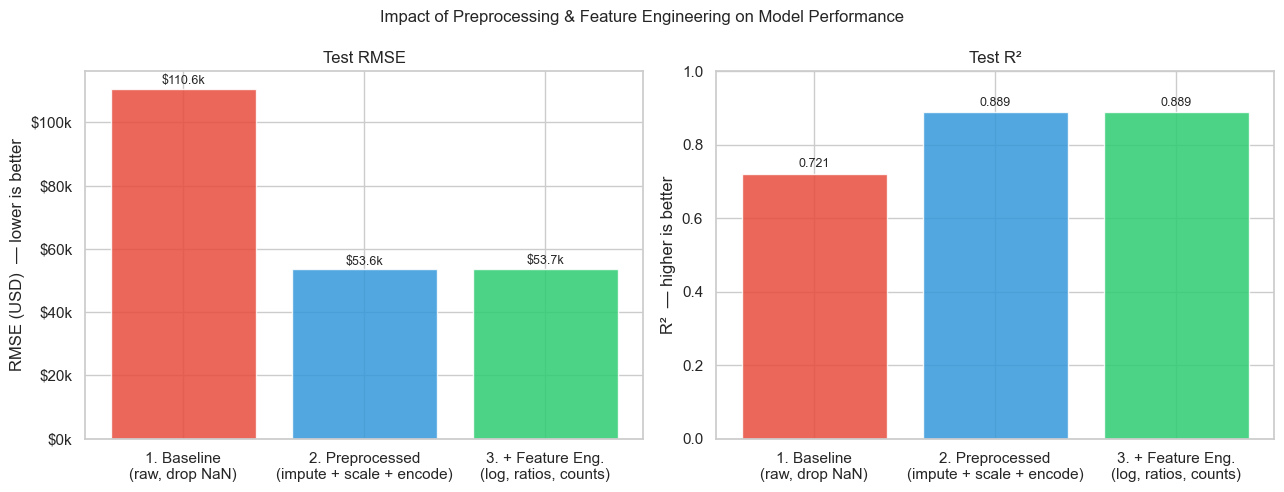

R² improvement from baseline to fully engineered: +0.1676

Key lesson: preprocessing alone (imputation + encoding + scaling) gives a major boost.
Feature engineering gives additional gains on top.


In [28]:
# Visualise the improvement
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

names = [n.replace('\n', '\n') for n in results.keys()]
rmses = [v['RMSE'] for v in results.values()]
r2s   = [v['R2']   for v in results.values()]
colours = ['#e74c3c', '#3498db', '#2ecc71']

bars0 = axes[0].bar(names, rmses, color=colours, alpha=0.85, edgecolor='white')
axes[0].set_ylabel('RMSE (USD)  — lower is better')
axes[0].set_title('Test RMSE')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
for bar, val in zip(bars0, rmses):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'${val/1000:.1f}k', ha='center', va='bottom', fontsize=9)

bars1 = axes[1].bar(names, r2s, color=colours, alpha=0.85, edgecolor='white')
axes[1].set_ylabel('R²  — higher is better')
axes[1].set_title('Test R²')
axes[1].set_ylim(0, 1)
for bar, val in zip(bars1, r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Impact of Preprocessing & Feature Engineering on Model Performance', fontsize=12)
plt.tight_layout()
plt.show()

baseline_r2  = list(results.values())[0]['R2']
engineered_r2 = list(results.values())[2]['R2']
print(f'R² improvement from baseline to fully engineered: {engineered_r2 - baseline_r2:+.4f}')
print()
print('Key lesson: preprocessing alone (imputation + encoding + scaling) gives a major boost.')
print('Feature engineering gives additional gains on top.')

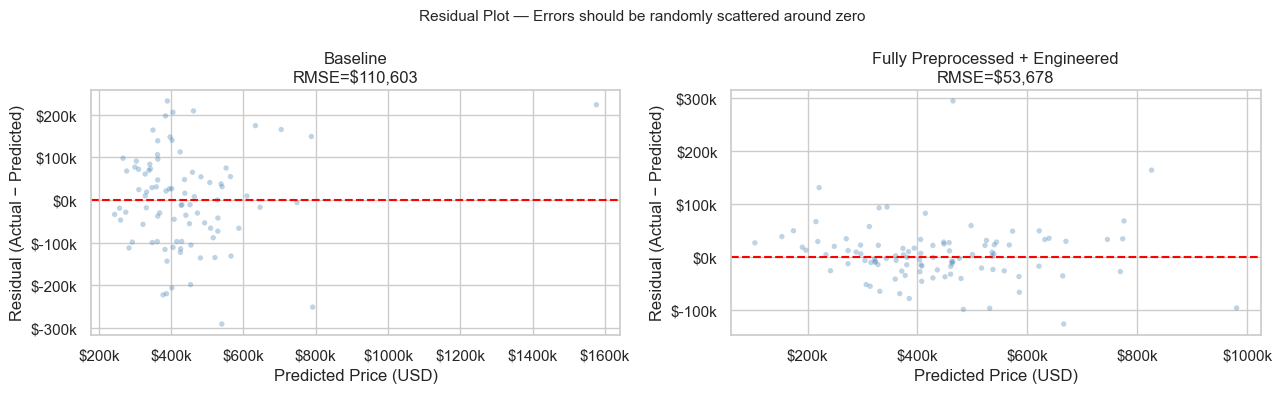

Good residual plot: randomly scattered around 0, no funnel shape, no curves.
Funnel shape (wider at high predictions) = heteroscedasticity → try log(price) as target.
Curve pattern = non-linear relationship → add polynomial features or use a non-linear model.


In [29]:
# Residual plot — understanding where the model still struggles
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (label, y_true, y_pred) in zip(axes, [
    ('Baseline',    yb_te, y_base_pred),
    ('Fully Preprocessed + Engineered', ye_te, y_eng_pred),
]):
    residuals = y_true - y_pred
    ax.scatter(y_pred, residuals, alpha=0.35, s=15, color='steelblue', edgecolors='none')
    ax.axhline(0, color='red', lw=1.5, ls='--')
    ax.set_xlabel('Predicted Price (USD)')
    ax.set_ylabel('Residual (Actual − Predicted)')
    ax.set_title(f'{label}\nRMSE=${np.sqrt(mean_squared_error(y_true, y_pred)):,.0f}')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.suptitle('Residual Plot — Errors should be randomly scattered around zero', fontsize=11)
plt.tight_layout()
plt.show()

print('Good residual plot: randomly scattered around 0, no funnel shape, no curves.')
print('Funnel shape (wider at high predictions) = heteroscedasticity → try log(price) as target.')
print('Curve pattern = non-linear relationship → add polynomial features or use a non-linear model.')

---
## 10. Summary — The Preprocessing Checklist

Copy this into every new project and work through it top to bottom.

### Step 1: Load & Inspect
```python
df.shape          # rows, columns
df.dtypes         # correct types?
df.isnull().sum() # missing values
df.describe()     # numeric summary
df.head(10)       # sanity check
```

### Step 2: Handle Missing Values
| What you find | What to do |
|---|---|
| < 1% missing, continuous, symmetric | Fill mean |
| < 5% missing, continuous, skewed/outliers | Fill median |
| Categorical | Fill mode |
| Missing is informative (MNAR) | Add `col_is_missing` flag, then fill |
| > 50% missing | Drop the column |

### Step 3: Encode Categorical Columns
| Category type | Encoding |
|---|---|
| Ordinal (Poor < Good < Excellent) | OrdinalEncoder |
| Nominal, low cardinality (< 10 levels) | OneHotEncoder |
| Nominal, high cardinality (> 10 levels) | Target encoding or embedding |

### Step 4: Detect & Treat Outliers
- Use IQR and Z-score to find candidates
- Investigate before removing
- Prefer capping or log-transform over deletion

### Step 5: Scale Features
| Model type | Scaling needed? | Best scaler |
|---|---|---|
| Linear/Logistic Regression, SVM, KNN | **YES** | StandardScaler |
| Neural Networks | **YES** | MinMaxScaler |
| Random Forest, XGBoost, LightGBM | **No** | — |
| Data has many outliers | **YES** | RobustScaler |

### Step 6: Engineer Features
- Log/sqrt transform right-skewed features
- Create ratio features (area / rooms)
- Bin continuous features when relationship is step-like
- Add interaction terms when domain knowledge suggests joint effects

### Step 7: Select Features
- Drop near-zero variance columns
- Drop features with |r| < 0.05 with the target (unless you have domain reason to keep)
- Use SelectKBest or RFE to rank remaining features

### Step 8: Build a Pipeline
```python
# Always:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

pipeline = Pipeline([
    ('prep',  ColumnTransformer([...])),
    ('model', YourModel()),
])

pipeline.fit(X_train, y_train)   # preprocessor never sees X_test
pipeline.score(X_test, y_test)
```

---

**What comes next?**  
Now that data is clean and features are engineered, you are ready to experiment with:
- Regularised linear models (Ridge, Lasso) — handle multicollinearity
- Ensemble models (Random Forest, Gradient Boosting) — handle non-linearities without scaling
- Cross-validation — reliable model evaluation beyond a single train/test split

In [30]:
# Final summary: what the preprocessed dataset looks like
final_feature_names = (
    numeric_features
    + ['log_area', 'total_rooms', 'amenity_score', 'sqft_per_room']
    + ordinal_features
    + nominal_features
)

print('=' * 60)
print('PREPROCESSING SUMMARY')
print('=' * 60)
print()
print(f'Original dataset:      {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')
print(f'Missing values:        {df_raw.isnull().sum().sum()} cells')
print()
print('Transformations applied:')
print('  ✓ Missing values imputed     (median for numeric, mode for categorical)')
print('  ✓ Outliers capped            (luxury area_sqft winsorised at 99th pct)')
print('  ✓ Ordinal encoding           (condition → 0..3)')
print('  ✓ One-hot encoding           (neighborhood → 3 binary columns)')
print('  ✓ Standard scaling           (all numeric features)')
print('  ✓ Log transform              (area_sqft, price)')
print('  ✓ Engineered features        (total_rooms, sqft_per_room, amenity_score)')
print()
print('Model performance (Linear Regression):')
for name, metrics in results.items():
    clean = name.replace('\n', ' ')
    print(f'  {clean:40}   R² = {metrics["R2"]:.4f}')
print()
print('=' * 60)

PREPROCESSING SUMMARY

Original dataset:      500 rows × 11 columns
Missing values:        95 cells

Transformations applied:
  ✓ Missing values imputed     (median for numeric, mode for categorical)
  ✓ Outliers capped            (luxury area_sqft winsorised at 99th pct)
  ✓ Ordinal encoding           (condition → 0..3)
  ✓ One-hot encoding           (neighborhood → 3 binary columns)
  ✓ Standard scaling           (all numeric features)
  ✓ Log transform              (area_sqft, price)
  ✓ Engineered features        (total_rooms, sqft_per_room, amenity_score)

Model performance (Linear Regression):
  1. Baseline (raw, drop NaN)                R² = 0.7211
  2. Preprocessed (impute + scale + encode)   R² = 0.8890
  3. + Feature Eng. (log, ratios, counts)    R² = 0.8887

